<a href="https://colab.research.google.com/github/KimMinWoooo/Hands-on-ML-repo/blob/main/10_neural_nets_with_keras_1a_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Chapter 10-1 – Introduction to Artificial Neural Networks with Keras**

_This notebook contains all the sample code and solutions to the exercises in chapter 10._

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/ageron/handson-ml2/blob/master/10_neural_nets_with_keras.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

20192576 김민우 HW1 제출

# Setup

First, let's import a few common modules, ensure MatplotLib plots figures inline and prepare a function to save the figures. We also check that Python 3.5 or later is installed (although Python 2.x may work, it is deprecated so we strongly recommend you use Python 3 instead), as well as Scikit-Learn ≥0.20 and TensorFlow ≥2.0.

In [ ]:
# Python ≥3.7 is required
import sys
print("Python: ", sys.version_info)
assert sys.version_info >= (3, 7)

from packaging import version
import sklearn
print(sklearn.__version__)
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
except Exception:
    pass

# TensorFlow ≥2.8.0 is required
import tensorflow as tf
print("TF version: ", tf.__version__)
assert version.parse(tf.__version__) >= version.parse("2.8.0")

# GPU check
import tensorflow as tf
if tf.test.gpu_device_name():
    print('Default GPU Device: {}'.format(tf.test.gpu_device_name()))
else:
    print("Please install GPU version of TF")

# GPU check
if not "google.colab" in sys.modules:
    from tensorflow.python.client import device_lib
    print("============")
    print('Device Test')
    print("============")
    print(device_lib.list_local_devices()[0])
    print(device_lib.list_local_devices()[1])

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# Where to save the figures
from pathlib import Path

IMAGES_PATH = Path() / "images" / "ann"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

Python:  sys.version_info(major=3, minor=11, micro=11, releaselevel='final', serial=0)
1.6.1
Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
TF version:  2.18.0
Please install GPU version of TF


# From Biological to Artificial Neurons
## Perceptrons

**Note**: we set `max_iter` and `tol` explicitly to avoid warnings about the fact that their default value will change in future versions of Scikit-Learn.

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0)  # Iris setosa

per_clf = Perceptron(random_state=42)
per_clf.fit(X, y)

X_new = [[2, 0.5], [3, 1]]
y_pred = per_clf.predict(X_new)  # predicts True and False for these 2 flowers

In [ ]:
y_pred

array([ True, False])

The `Perceptron` is equivalent to a `SGDClassifier` with `loss="perceptron"`, no regularization, and a constant learning rate equal to 1:

In [ ]:
# extra code – shows how to build and train a Perceptron

from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(loss="perceptron", penalty=None,
                        learning_rate="constant", eta0=1, random_state=42)
sgd_clf.fit(X, y)
assert (sgd_clf.coef_ == per_clf.coef_).all()
assert (sgd_clf.intercept_ == per_clf.intercept_).all()

When the Perceptron finds a decision boundary that properly separates the classes, it stops learning. This means that the decision boundary is often quite close to one class:

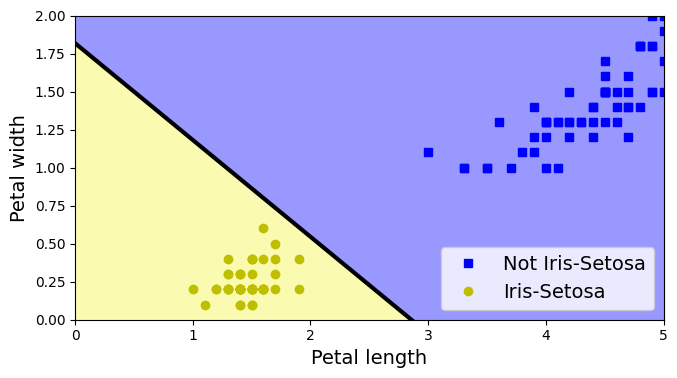

In [ ]:
# extra code – plots the decision boundary of a Perceptron on the iris dataset
a = -per_clf.coef_[0][0] / per_clf.coef_[0][1]
b = -per_clf.intercept_ / per_clf.coef_[0][1]

axes = [0, 5, 0, 2]

x0, x1 = np.meshgrid(
        np.linspace(axes[0], axes[1], 500).reshape(-1, 1),
        np.linspace(axes[2], axes[3], 200).reshape(-1, 1),
    )
X_new = np.c_[x0.ravel(), x1.ravel()]
y_predict = per_clf.predict(X_new)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(7, 4))
plt.plot(X[y==0, 0], X[y==0, 1], "bs", label="Not Iris-Setosa")
plt.plot(X[y==1, 0], X[y==1, 1], "yo", label="Iris-Setosa")
plt.plot([axes[0], axes[1]], [a * axes[0] + b, a * axes[1] + b], "k-", linewidth=3)

from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#9898ff', '#fafab0'])

plt.contourf(x0, x1, zz, cmap=custom_cmap)
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(loc="lower right", fontsize=14)
plt.axis(axes)

save_fig("perceptron_iris_plot")
plt.show()

## Activation functions

In [ ]:
from scipy.special import expit as sigmoid
#def sigmoid(z):
#    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def derivative(f, z, eps=0.000001):
    return (f(z + eps) - f(z - eps))/(2 * eps)

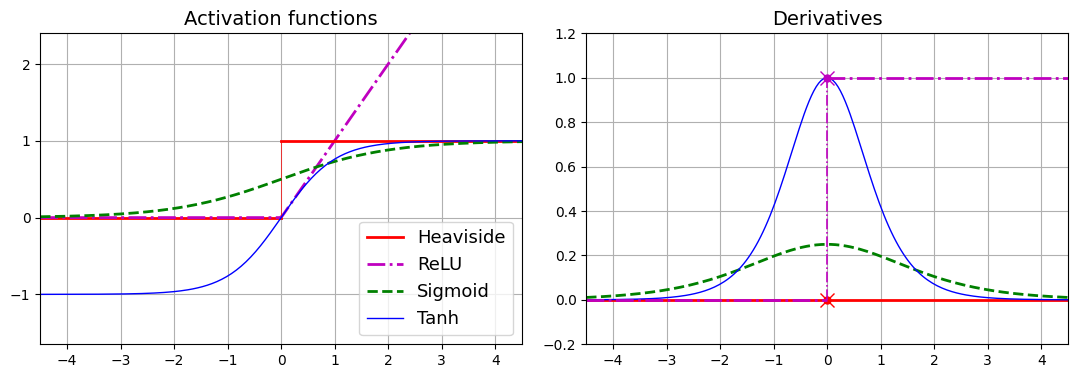

In [ ]:
max_z = 4.5
z = np.linspace(-max_z, max_z, 200)

plt.figure(figsize=(11, 4))

plt.subplot(121)
plt.plot([-max_z, 0], [0, 0], "r-", linewidth=2, label="Heaviside")
plt.plot(z, relu(z), "m-.", linewidth=2, label="ReLU")
plt.plot([0, 0], [0, 1], "r-", linewidth=0.5)
plt.plot([0, max_z], [1, 1], "r-", linewidth=2)
plt.plot(z, sigmoid(z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, np.tanh(z), "b-", linewidth=1, label="Tanh")
plt.grid(True)
plt.title("Activation functions")
plt.axis([-max_z, max_z, -1.65, 2.4])
plt.gca().set_yticks([-1, 0, 1, 2])
plt.legend(loc="lower right", fontsize=13)

plt.subplot(122)
plt.plot(z, derivative(np.sign, z), "r-", linewidth=2, label="Heaviside")
plt.plot(0, 0, "ro", markersize=5)
plt.plot(0, 0, "rx", markersize=10)
plt.plot(z, derivative(sigmoid, z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, derivative(np.tanh, z), "b-", linewidth=1, label="Tanh")
plt.plot([-max_z, 0], [0, 0], "m-.", linewidth=2)
plt.plot([0, max_z], [1, 1], "m-.", linewidth=2)
plt.plot([0, 0], [0, 1], "m-.", linewidth=1.2)
plt.plot(0, 1, "mo", markersize=5)
plt.plot(0, 1, "mx", markersize=10)
plt.grid(True)
plt.title("Derivatives")
plt.axis([-max_z, max_z, -0.2, 1.2])

save_fig("activation_functions_plot")
plt.show()

### ==P1. activation functions==
#### 위의 cell들을 실행후 동작을 설명
#### Answer:
4개의 activation function 및 미분에 대한 정의와 각 함수의 그림

- Heaviside step function: 0 이하에서는 0, 0 초과에서는 1을 반환,
미분 : 0
- ReLU (Rectified Linear Unit): 0 이하에서는 0, 0 초과에서는 입력값을 그대로 반환 , 미분 : 0 이하에서는 0, 0 초과부터는 입력 값 그대로 반환

- Sigmoid: S자 곡선을 가지며, 0~1 사이의 값으로 압축, 미분 : 해당 함수에서 구한 공식에 의해 도출

- Tanh (Hyperbolic Tangent): -1~1 사이의 값으로 변환, 미분 : 해당 함수에서 구한 공식에 의해 도출

## Regression MLPs

In [ ]:
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(labels, predictions):
        return mean_squared_error(labels, predictions, squared=False)

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

mlp_reg = MLPRegressor(hidden_layer_sizes=[50, 50, 50], random_state=42)
pipeline = make_pipeline(StandardScaler(), mlp_reg)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_valid)
rmse = root_mean_squared_error(y_valid, y_pred)

In [ ]:
rmse

0.5053326657968684

### ==P2. Regression MLPs=
#### 위의 cell들을 실행후 동작을 설명
#### Answer:
California Housing 데이터셋을 train, validation, test set으로 분리한 후 MLPRegressor 모델과 standard scaler를 이용하여 학습시킨후 validation dataset에 대해 rmse를 값을 계산한 결과 0.505를 얻음.

## Classification MLPs

In [ ]:
# extra code – this was left as an exercise for the reader

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

iris = load_iris()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    iris.data, iris.target, test_size=0.1, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42)

mlp_clf = MLPClassifier(hidden_layer_sizes=[5], max_iter=10_000,
                        random_state=42)
pipeline = make_pipeline(StandardScaler(), mlp_clf)
pipeline.fit(X_train, y_train)
accuracy = pipeline.score(X_valid, y_valid)
accuracy

1.0

### ==P3. Classification MLPs==
#### 위의 cell들을 실행후 동작을 설명
#### Answer:
-
Iris 데이터셋을 train, validation, test 세트로 나눈 후, StandardScaler로 데이터를 표준화한 뒤 은닉층 1개(뉴런 5개)를 가진 MLPClassifier 모델을 학습시켰으며, 10,000번의 반복 학습 후 validation 데이터셋에 대한 정확도를 평가하였습니다.
  
  

First let's import TensorFlow and Keras.

In [ ]:
#import keras
from tensorflow import keras
keras.__version__

'3.8.0'

### Exercise 10.1
Define and plot activation functions ELU, leaky ReLU and ReLU6 using keras.activation functions.


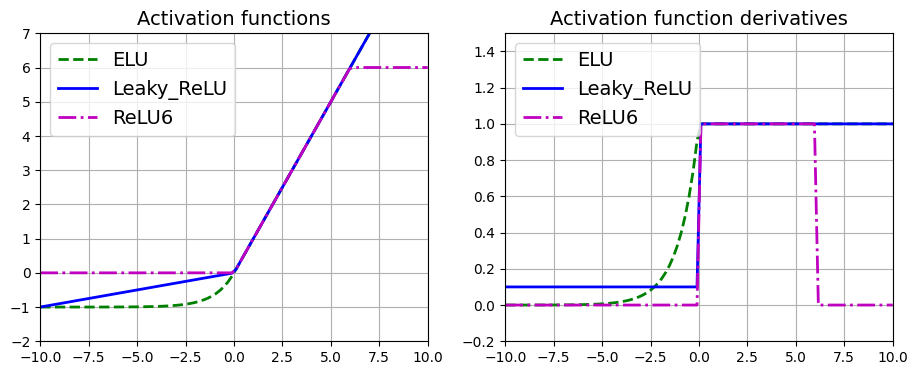

In [ ]:
#Exercise 10.1
# Define activation functions using keras.activations


import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.activations import elu, relu

# ReLU6 및 Leaky ReLU 정의
def relu6(x):
    return tf.minimum(relu(x), 6)

def leaky_relu(x, alpha=0.1):
    return tf.where(x >= 0, x, alpha * x)

# 미분 함수
def derivative(f, x, eps=1e-5):
    return (f(x + eps) - f(x - eps)) / (2 * eps)

# 입력 값 생성
z = np.linspace(-10, 10, 100)

# 그래프 그리기
plt.figure(figsize=(11, 4))

plt.subplot(121)
plt.plot(z, elu(z), "g--", linewidth=2, label="ELU")
plt.plot(z, leaky_relu(z), "b-", linewidth=2, label="Leaky_ReLU")
plt.plot(z, relu6(z), "m-.", linewidth=2, label="ReLU6")
plt.grid(True)
plt.legend(loc="upper left", fontsize=14)
plt.title("Activation functions", fontsize=14)
plt.axis([-10, 10, -2, 7])

plt.subplot(122)
plt.plot(z, derivative(elu, z), "g--", linewidth=2, label="ELU")
plt.plot(z, derivative(leaky_relu, z), "b-", linewidth=2, label="Leaky_ReLU")
plt.plot(z, derivative(relu6, z), "m-.", linewidth=2, label="ReLU6")
plt.grid(True)
plt.legend(loc="upper left", fontsize=14)
plt.title("Activation function derivatives", fontsize=14)
plt.axis([-10, 10, -0.2, 1.5])

plt.show()


# Implementing MLPs with Keras
## Building an Image Classifier Using the Sequential API
### Using Keras to load the dataset

Let's start by loading the fashion MNIST dataset. Keras has a number of functions to load popular datasets in `tf.keras.datasets`. The dataset is already split for you between a training set (60,000 images) and a test set (10,000 images), but it can be useful to split the training set further to have a validation set. We'll use 55,000 images for training, and 5,000 for validation.

In [ ]:
fashion_mnist = keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


The training set contains 60,000 grayscale images, each 28x28 pixels:

In [ ]:
print(X_train_full.shape)
print(y_train_full.shape)

(60000, 28, 28)
(60000,)


Each pixel intensity is represented as a byte (0 to 255):

In [ ]:
X_train_full.dtype

dtype('uint8')

Let's split the full training set into a validation set and a (smaller) training set. We also scale the pixel intensities down to the 0-1 range and convert them to floats, by dividing by 255.

In [ ]:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

In [ ]:
print(X_train.shape)
print(X_train.dtype)

(55000, 28, 28)
float64


### ==P4. Using Keras to load the dataset (1)==
#### 1. dataset의 이름: Fashion MNIST
#### 2. Original dataset의 data의 종류와 수:
데이터의 종류: 이미지 데이터 (28x28 픽셀 크기 이미지)

데이터의 수: 훈련 데이터 60,000개, 테스트 데이터 10,000개
#### 3. 데이터를 255로 나눈 이후 데이터의 변화 설명: 원본 데이터는 0부터 255까지의 정수 값으로 되어 있으며, 이 값을 255로 나누면, 픽셀 값은 0과 1 사이의 실수 값으로 변환됩니다. 이렇게 하면 모델 학습에 적합한 형태로 데이터가 정규화되며, 학습 효율과 성능이 향상될 수 있습니다.

You can plot an image using Matplotlib's `imshow()` function, with a `'binary'`
 color map:

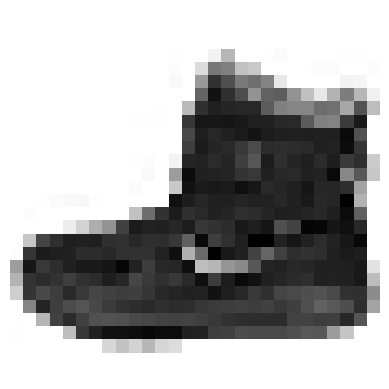

In [ ]:
plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

The labels are the class IDs (represented as uint8), from 0 to 9:

In [ ]:
y_train

array([9, 0, 0, ..., 9, 0, 2], dtype=uint8)

Here are the corresponding class names:

In [ ]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

So the first image in the training set is a coat:

In [ ]:
class_names[y_train[0]]

'Ankle boot'

The validation set contains 5,000 images, and the test set contains 10,000 images:

In [ ]:
X_valid.shape

(5000, 28, 28)

In [ ]:
X_test.shape

(10000, 28, 28)

Let's take a look at a sample of the images in the dataset:

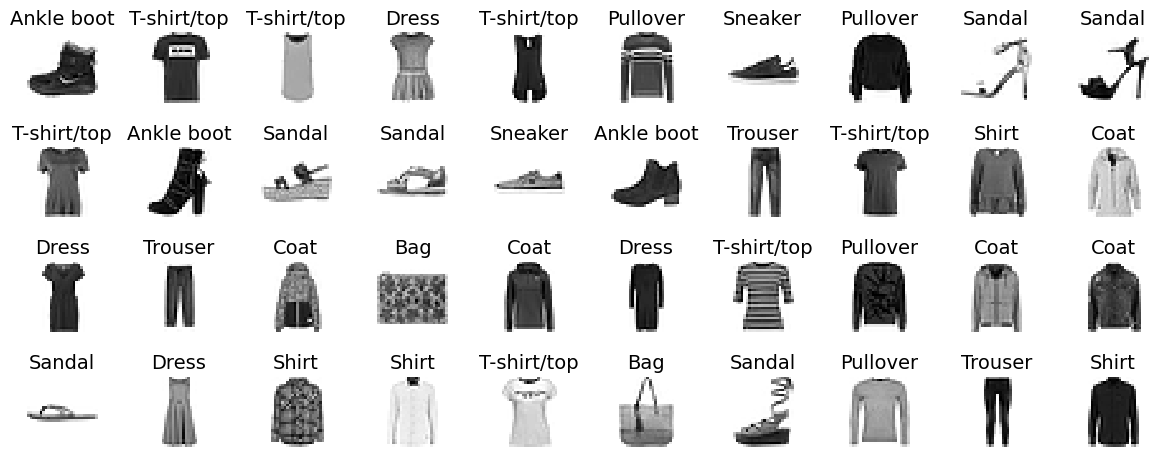

In [ ]:
# extra code – this cell generates and saves Figure 10–10

n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(class_names[y_train[index]])
plt.subplots_adjust(wspace=0.2, hspace=0.5)

save_fig("fashion_mnist_plot")
plt.show()

### ==P5. Using Keras to load the dataset (2)==
#### 아래 cell에 41번째 데이터의 그림과 label을 표시하는 코드를 작성하고 실행

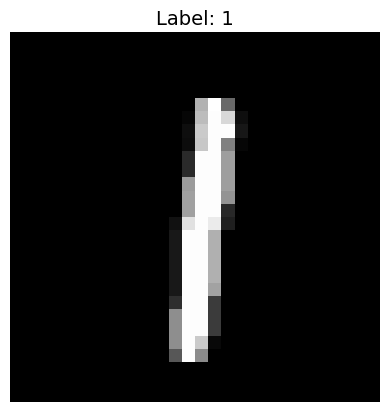

In [ ]:
# Plot and label the 41st data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 41번째 이미지 선택
index = 40
image = x_train[index]
label = y_train[index]

# 이미지 출력
plt.imshow(image, cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

### Creating the model using the Sequential API

In [ ]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.InputLayer(input_shape=[28, 28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
# extra code – clear the session to reset the name counters
keras.backend.clear_session()
#np.random.seed(42)
tf.random.set_seed(42)
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

### ==P.6 Creating the model using the Sequential API(1)==
#### 위에서 정의한  'model'의
#### 1. input neuron의 수: 28 * 28 = 784
#### 2. hidden layer의 수와 각 hidden layer의 neuron의 수: hidden layer는 총 2개
1번째 히든 레이어 뉴런 수 : 300 , 2번째 히든 레이어 뉴런 수 : 100
#### 3. 출력층의 neuron의 수: 소프트맥스 함수가 적용 -> 뉴런 수 : 10
#### 4. 총 parameter의 수: 266,610개

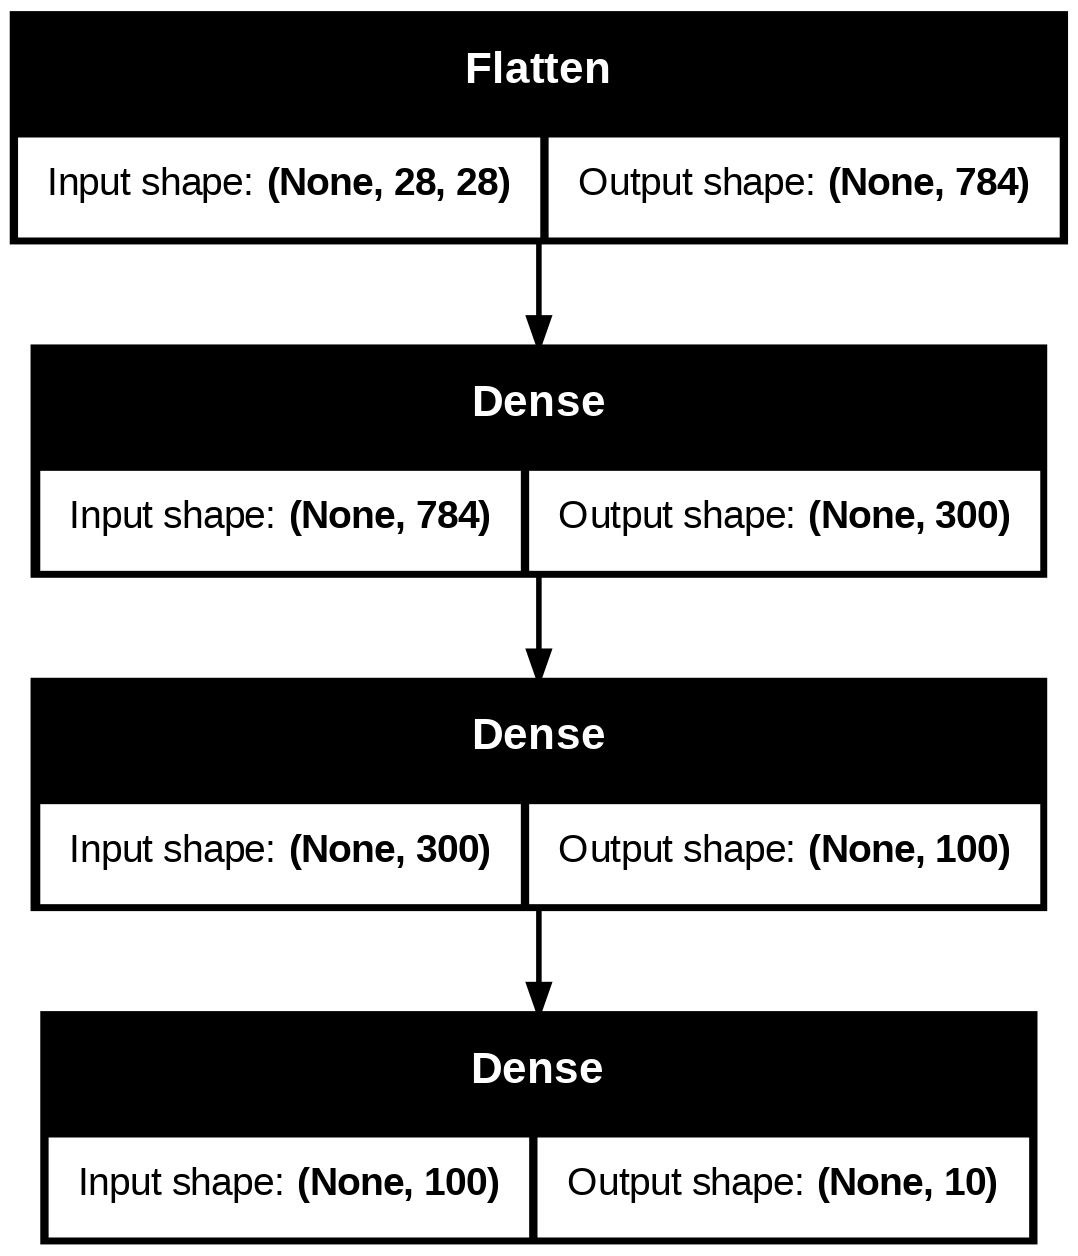

In [ ]:
# extra code – another way to display the model's architecture
keras.utils.plot_model(model, "my_fashion_mnist_model.png", show_shapes=True)

In [ ]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [ ]:
hidden1 = model.layers[1]
hidden1.name

'dense'

In [ ]:
model.get_layer(hidden1.name) is hidden1

True

In [ ]:
weights, biases = hidden1.get_weights()
weights

array([[ 0.03724114,  0.02715238, -0.07437368, ..., -0.03424704,
         0.05614093, -0.05545449],
       [ 0.02269112,  0.03732919,  0.01179266, ...,  0.04665136,
         0.0384471 ,  0.01158372],
       [ 0.0085081 , -0.07365931,  0.04815663, ..., -0.06813864,
        -0.01045609,  0.04461966],
       ...,
       [ 0.07322446, -0.00572064,  0.05743933, ..., -0.05607152,
        -0.02418165,  0.03685002],
       [-0.05329914,  0.03698137,  0.01736508, ..., -0.01543074,
        -0.03961179,  0.05073835],
       [ 0.04359759, -0.05869986,  0.05307506, ...,  0.06835082,
        -0.04141879, -0.0344213 ]], dtype=float32)

In [ ]:
weights.shape

(784, 300)

In [ ]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [ ]:
biases.shape

(300,)

### ==P.7 Creating the model using the Sequential API(2)==
####  마지막 input neuron과 첫번째 hidden layer의 마지막 neuron 사이의 weight와 bias의 초기값(소수점 4자리이후 버림 )
#### Answer:
- weight 초기 값 : -0.0555
- bias의 초기 값 : 0.0